In [ ]:
# Student Progress Scoring & Module Outcome Regression ----Code4Kids – Beginner Level Project

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = 'code4kids_student_progress_v2 - code4kids_student_progress_v2.csv'
df = pd.read_csv(file_path)

In [3]:
df.head()

,student_id,class_id,teacher_id,grade_level,classroom_size,device,teacher_experience_years,teacher_quality,total_modules,modules_completed,...,is_overstudy,pretest_score,assignment_1_score,assignment_2_score,last_7_days_activity_count,days_since_last_activity,num_messages_to_teacher,mentorship_sessions,internet_reliability,is_native_speaker
0,S100000,C1000,T200,6,36,desktop,1,0.433,12,10.0,...,False,63.571571,85.762403,54.532053,14,0,2,2,Low,True
1,S100001,C1001,T201,8,44,tablet,6,0.300,12,11.0,...,False,74.228678,85.465859,66.596005,21,3,1,3,High,True
2,S100002,C1002,T202,7,45,desktop,2,0.790,12,12.0,...,False,54.454443,72.043568,84.026189,20,4,2,0,Medium,False
3,S100003,C1003,T203,6,32,mobile,1,0.760,12,9.0,...,False,66.319149,NaN,76.416180,12,0,1,1,High,True
4,S100004,C1004,T204,5,32,mobile,7,0.728,12,10.0,...,False,47.389233,92.108291,75.214785,14,1,3,0,High,True


In [ ]:
# Observation ---The dataset contains student learning activity information, quiz scores, engagement metrics, and the target variable `final_score`.

In [4]:
print('Dataset Shape:', df.shape)

Dataset Shape: (5000, 34)


In [5]:
print(df.columns)

Index(['student_id', 'class_id', 'teacher_id', 'grade_level', 'classroom_size',
       'device', 'teacher_experience_years', 'teacher_quality',
       'total_modules', 'modules_completed', 'avg_time_per_module',
       'total_time_spent', 'attempts_per_module', 'hints_used', 'early_quiz1',
       'early_quiz2', 'early_quiz3', 'forum_posts', 'peer_reviews_completed',
       'assignment_on_time_pct', 'prior_score', 'group_label', 'final_score',
       'is_cheater', 'is_overstudy', 'pretest_score', 'assignment_1_score',
       'assignment_2_score', 'last_7_days_activity_count',
       'days_since_last_activity', 'num_messages_to_teacher',
       'mentorship_sessions', 'internet_reliability', 'is_native_speaker'],
      dtype='object')


In [6]:
print(df.dtypes)

student_id                     object
class_id                       object
teacher_id                     object
grade_level                     int64
classroom_size                  int64
device                         object
teacher_experience_years        int64
teacher_quality               float64
total_modules                   int64
modules_completed             float64
avg_time_per_module           float64
total_time_spent                int64
attempts_per_module             int64
hints_used                      int64
early_quiz1                   float64
early_quiz2                   float64
early_quiz3                   float64
forum_posts                     int64
peer_reviews_completed          int64
assignment_on_time_pct        float64
prior_score                   float64
group_label                    object
final_score                   float64
is_cheater                       bool
is_overstudy                     bool
pretest_score                 float64
assignment_1

In [ ]:
# Observation----

# The dataset contains both numerical and categorical variables.
# Some columns are identifiers and some are engagement-related features.

In [7]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

modules_completed         150
avg_time_per_module       150
early_quiz1               150
assignment_on_time_pct    150
assignment_1_score        150
dtype: int64

In [8]:
df.describe()

,grade_level,classroom_size,teacher_experience_years,teacher_quality,total_modules,modules_completed,avg_time_per_module,total_time_spent,attempts_per_module,hints_used,...,assignment_on_time_pct,prior_score,final_score,pretest_score,assignment_1_score,assignment_2_score,last_7_days_activity_count,days_since_last_activity,num_messages_to_teacher,mentorship_sessions
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.0,4850.000000,4850.000000,5000.000000,5000.000000,5000.000000,...,4850.000000,5000.000000,5000.000000,5000.000000,4850.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,6.037000,38.04580,4.331200,0.610624,12.0,7.783299,34.937862,284.699800,1.805800,2.155200,...,0.784716,72.067542,66.058008,57.682043,75.628463,72.202166,15.00920,1.967600,1.987800,0.500600
std,1.286997,5.31663,1.814432,0.213488,0.0,2.632947,12.145113,181.618534,1.351611,1.447042,...,0.137621,10.230945,15.899491,9.597917,14.936341,15.689837,3.79821,3.395476,1.427746,0.863104
min,4.000000,20.00000,1.000000,0.300000,12.0,0.000000,5.000000,0.000000,0.000000,0.000000,...,0.262000,29.480000,4.300000,20.313622,16.726228,13.893864,4.00000,0.000000,0.000000,0.000000
25%,5.000000,34.00000,3.000000,0.419250,12.0,6.000000,26.772500,177.000000,1.000000,1.000000,...,0.691000,65.120000,56.987500,51.182758,65.645400,61.617115,12.00000,0.000000,1.000000,0.000000
50%,6.000000,38.00000,5.000000,0.640000,12.0,8.000000,35.080000,258.000000,2.000000,2.000000,...,0.790000,71.940000,68.390000,57.655525,76.637610,73.047966,15.00000,1.000000,2.000000,0.000000
75%,7.000000,42.00000,6.000000,0.799000,12.0,10.000000,43.307500,360.250000,3.000000,3.000000,...,0.888000,79.042500,76.952500,64.206706,86.729516,83.662745,17.00000,2.000000,3.000000,1.000000
max,8.000000,58.00000,9.000000,0.950000,12.0,12.000000,76.660000,2810.000000,7.000000,10.000000,...,1.000000,100.000000,100.000000,89.438438,100.000000,100.000000,30.00000,20.000000,10.000000,3.000000


In [ ]:
# Exploratory Data Analysis (EDA)

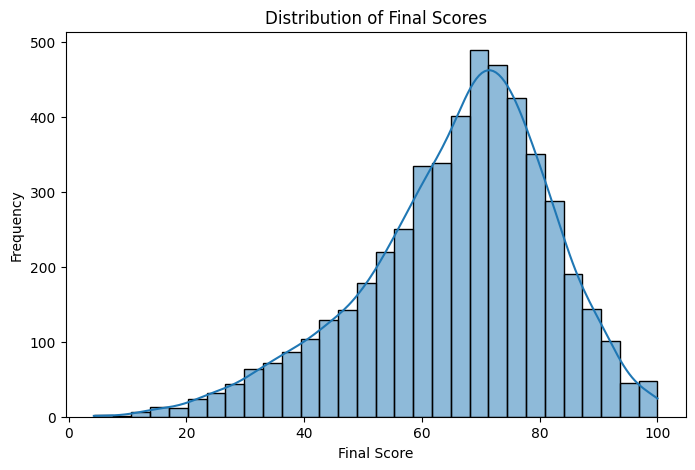

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['final_score'], bins=30, kde=True)
plt.title('Distribution of Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# observation --- Final scores are approximately normally distributed.
# Conclusion --- Regression models can perform well on this dataset.

In [ ]:
## Correlation Heatmap

In [12]:
numeric_df = df.select_dtypes(include=np.number)   #Selected numerical columns

In [13]:
corr_matrix = numeric_df.corr()     # Correlation matrix

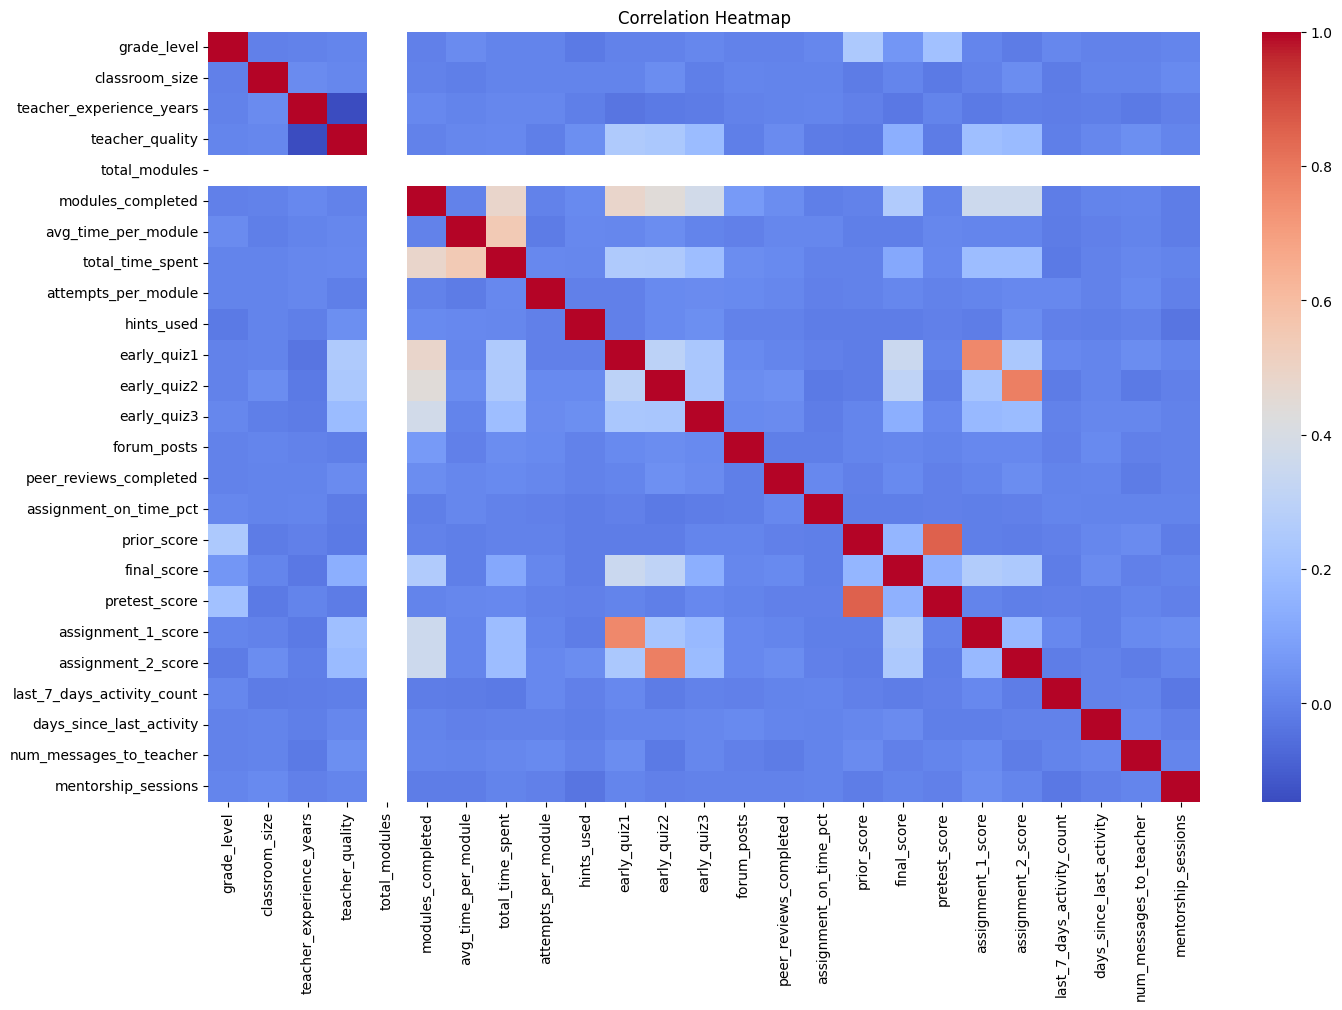

In [14]:
# Plot heatmap

plt.figure(figsize=(16,10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# observation ---Early quiz scores, assignment scores, modules completed, and pretest scores are positively correlated with final scores.

In [ ]:
# Relationship Between Early Quiz Scores and Final Score

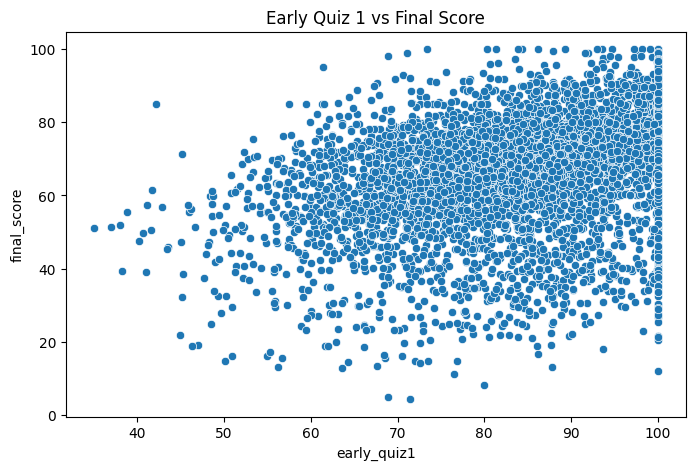

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='early_quiz1', y='final_score', data=df)
plt.title('Early Quiz 1 vs Final Score')
plt.show()

In [ ]:
# Observation---- Students with higher early quiz scores tend to achieve higher final scores.
# Conclusion --- Early quiz performance is a strong indicator of final outcomes.

In [ ]:
# Data Cleaning and Feature Selection

In [16]:
# dropping unnecessary columns

columns_to_drop = [
    'student_id',
    'class_id',
    'teacher_id',
    'group_label',
    'is_cheater',
    'is_overstudy'
]

In [17]:
df.head()

,student_id,class_id,teacher_id,grade_level,classroom_size,device,teacher_experience_years,teacher_quality,total_modules,modules_completed,...,is_overstudy,pretest_score,assignment_1_score,assignment_2_score,last_7_days_activity_count,days_since_last_activity,num_messages_to_teacher,mentorship_sessions,internet_reliability,is_native_speaker
0,S100000,C1000,T200,6,36,desktop,1,0.433,12,10.0,...,False,63.571571,85.762403,54.532053,14,0,2,2,Low,True
1,S100001,C1001,T201,8,44,tablet,6,0.300,12,11.0,...,False,74.228678,85.465859,66.596005,21,3,1,3,High,True
2,S100002,C1002,T202,7,45,desktop,2,0.790,12,12.0,...,False,54.454443,72.043568,84.026189,20,4,2,0,Medium,False
3,S100003,C1003,T203,6,32,mobile,1,0.760,12,9.0,...,False,66.319149,NaN,76.416180,12,0,1,1,High,True
4,S100004,C1004,T204,5,32,mobile,7,0.728,12,10.0,...,False,47.389233,92.108291,75.214785,14,1,3,0,High,True


In [18]:
# creating cleaned dataset

clean_df = df.drop(columns=columns_to_drop)

In [19]:
# Features and target
X = clean_df.drop('final_score', axis=1)
y = clean_df['final_score']

In [ ]:
# Observation----Identifier columns and restricted synthetic columns are removed.

In [ ]:
# Separate Numerical and Categorical Features

In [21]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns   # Numerical columns

In [22]:
categorical_features = X.select_dtypes(include=['object', 'bool']).columns   # Categorical Columns

In [23]:
print('Numerical Features:', numeric_features)
print('Categorical Features:', categorical_features)

Numerical Features: Index(['grade_level', 'classroom_size', 'teacher_experience_years',
       'teacher_quality', 'total_modules', 'modules_completed',
       'avg_time_per_module', 'total_time_spent', 'attempts_per_module',
       'hints_used', 'early_quiz1', 'early_quiz2', 'early_quiz3',
       'forum_posts', 'peer_reviews_completed', 'assignment_on_time_pct',
       'prior_score', 'pretest_score', 'assignment_1_score',
       'assignment_2_score', 'last_7_days_activity_count',
       'days_since_last_activity', 'num_messages_to_teacher',
       'mentorship_sessions'],
      dtype='object')
Categorical Features: Index(['device', 'internet_reliability', 'is_native_speaker'], dtype='object')


In [ ]:
# Observation ----- The dataset contains both categorical and numerical data.

In [ ]:
# Data Preprocessing Pipeline

In [24]:
from sklearn.preprocessing import OneHotEncoder

In [25]:
# Numerical preprocessing

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [26]:
# Categorical preprocessing

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [27]:
# Combine preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
# Observation -----

# Missing numerical values are replaced with mean values.
# Categorical features are encoded into machine-readable format.

In [ ]:
##### Dataset is ready for ML

In [ ]:
# Spliting Data into Training and Testing Sets

In [28]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
print('Training Data Shape:', X_train.shape)
print('Testing Data Shape:', X_test.shape)

Training Data Shape: (4000, 27)
Testing Data Shape: (1000, 27)


In [ ]:
# Observation ---- 80% data is used for training and 20% for testing.

In [ ]:
# Conclusion --- The model can now be trained and evaluated properly.

In [ ]:
# Building Linear Regression Model

In [30]:
# Create pipeline

linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [31]:
# Train model
linear_model.fit(X_train, y_train)

# Predictions
linear_preds = linear_model.predict(X_test)

In [ ]:
# Observation ----Linear Regression learns relationships between engagement features and final scores.

In [32]:
# Evaluation metrics

mae = mean_absolute_error(y_test, linear_preds)
mse = mean_squared_error(y_test, linear_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, linear_preds)

In [33]:
print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R2 Score:', r2)

MAE: 10.791646908192325
MSE: 200.98083551743068
RMSE: 14.176770983458493
R2 Score: 0.20591585080634045


In [ ]:
## Observation :

#  Lower MAE and RMSE indicate better prediction accuracy.
# Higher R² score indicates better model performance.

In [34]:
# Random Forest pipeline

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [35]:
# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)

In [ ]:
### Observation :-

# Random Forest can capture non-linear relationships more effectively.

### Conclusion :-

# Ensemble learning often improves regression accuracy.


In [36]:
# Evaluation metrics

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mse = mean_squared_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_preds)

In [37]:
print('Random Forest MAE:', rf_mae)
print('Random Forest RMSE:', rf_rmse)
print('Random Forest R2 Score:', rf_r2)

Random Forest MAE: 10.71681235
Random Forest RMSE: 13.870095905611919
Random Forest R2 Score: 0.23989986819539044


In [ ]:
### Observation :-

# Random Forest generally produces better prediction accuracy than Linear Regression.

### Conclusion :-

# Random Forest is selected as the final prediction model.

In [ ]:
# Comparing Models

In [39]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R2 Score': [r2, rf_r2]
})

In [40]:
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,10.791647,14.176771,0.205916
1,Random Forest,10.716812,13.870096,0.239900


In [ ]:
### Observation :-

# Compare all model evaluation metrics side by side.

### Conclusion :-

# The best-performing model can be selected based on highest R² which is Random Forest and lowest RMSE which is also Random forest.

In [42]:
# Extract trained Random Forest model
rf_trained = rf_model.named_steps['model']

# Geting feature names after preprocessing
encoded_features = rf_model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(categorical_features)

all_features = list(numeric_features) + list(encoded_features)

# Feature importance
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_trained.feature_importances_
})

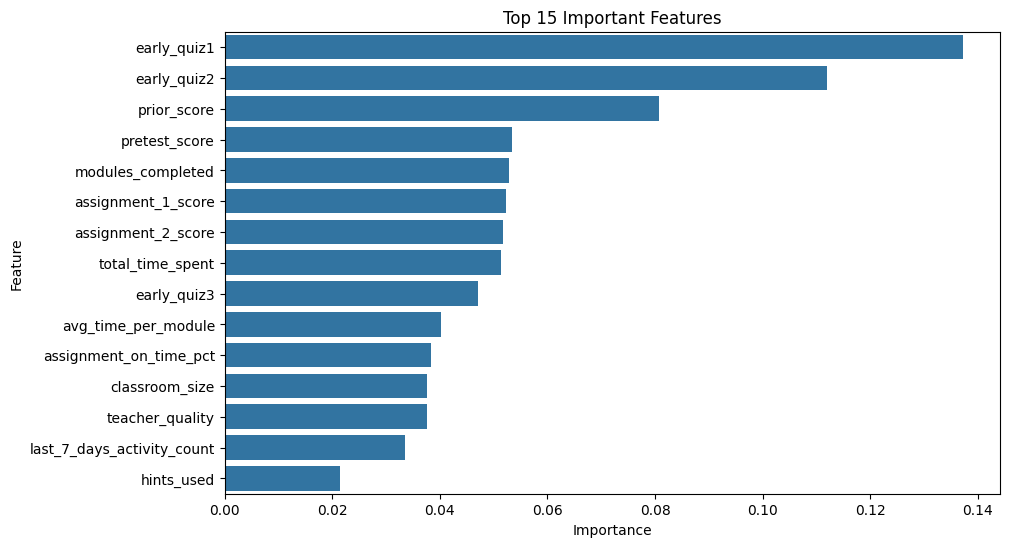

In [43]:
# Top 15 important features

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15)
)
plt.title('Top 15 Important Features')
plt.show()

In [ ]:
## Observation :-

# Early quiz scores, assignment scores, prior scores, and modules completed are highly important.

## Conclusion :-

# Student engagement and early performance strongly affect final outcomes.

In [ ]:
# Design an Early-Warning System

In [45]:
## Identify At-Risk Students

# Predicting final scores for all students
clean_df['predicted_final_score'] = rf_model.predict(X)

In [46]:
# Create risk category
clean_df['risk_category'] = clean_df['predicted_final_score'].apply(
    lambda x: 'High Risk' if x < 50 else ('Medium Risk' if x < 70 else 'Low Risk')
)

In [47]:
# View at-risk students
at_risk_students = clean_df[
    clean_df['risk_category'] == 'High Risk'
]

In [48]:
at_risk_students.head()

,grade_level,classroom_size,device,teacher_experience_years,teacher_quality,total_modules,modules_completed,avg_time_per_module,total_time_spent,attempts_per_module,...,assignment_1_score,assignment_2_score,last_7_days_activity_count,days_since_last_activity,num_messages_to_teacher,mentorship_sessions,internet_reliability,is_native_speaker,predicted_final_score,risk_category
14,5,35,desktop,2,0.648,12,6.0,29.67,178,1,...,67.564091,63.957886,11,0,1,0,High,True,49.51130,High Risk
16,5,32,desktop,2,0.300,12,4.0,34.63,138,4,...,62.940505,52.938072,22,0,1,0,High,True,49.20595,High Risk
18,6,33,mobile,5,0.384,12,9.0,45.83,412,4,...,86.450250,59.586927,13,0,0,0,High,True,48.90340,High Risk
34,8,38,mobile,1,0.820,12,7.0,61.23,428,2,...,60.122342,70.231784,13,0,1,0,High,True,38.63665,High Risk
35,7,28,desktop,4,0.726,12,8.0,45.01,360,2,...,100.000000,75.939849,14,4,2,0,High,True,49.40370,High Risk


In [ ]:
# Observation :- Students predicted to score below 50 are categorized as High Risk.

# Conclusion :-  Teachers can identify struggling students early.

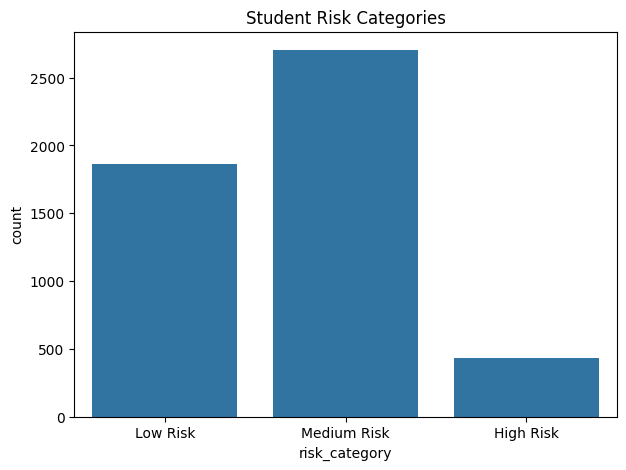

In [49]:
# Visualize Risk Categories

plt.figure(figsize=(7,5))
sns.countplot(x='risk_category', data=clean_df)
plt.title('Student Risk Categories')
plt.show()


In [ ]:
### Observation :- The chart displays the number of students in each risk group.

## Conclusion :- Teachers can prioritize support for high-risk students.

In [50]:
# Recommendation function

def recommendation(row):
    if row['risk_category'] == 'High Risk':
        return 'Immediate intervention and mentorship required'
    elif row['risk_category'] == 'Medium Risk':
        return 'Provide additional practice and monitoring'
    else:
        return 'Continue regular learning support'

In [51]:
# Applying recommendations
clean_df['teacher_recommendation'] = clean_df.apply(recommendation, axis=1)

# Displaying recommendations
clean_df[[
    'predicted_final_score',
    'risk_category',
    'teacher_recommendation'
]].head()

,predicted_final_score,risk_category,teacher_recommendation
0,84.19375,Low Risk,Continue regular learning support
1,73.89390,Low Risk,Continue regular learning support
2,60.39035,Medium Risk,Provide additional practice and monitoring
3,61.22835,Medium Risk,Provide additional practice and monitoring
4,63.42175,Medium Risk,Provide additional practice and monitoring


In [ ]:
# Observation ---- Recommendations are automatically generated based on predicted performance.

# Conclusion --- The system supports teachers in taking timely remedial actions.

In [52]:
# Saving final predictions

clean_df.to_csv('student_early_warning_results.csv', index=False)

print('Results saved successfully!')

Results saved successfully!


In [ ]:
# observatoin ---- processed dataset and predictions are stored for future use.

In [ ]:
# Final Conclusion ::-

## Overall Findings ----

# Student engagement metrics are strong predictors of academic performance.
# Early quizzes and assignment scores significantly influence final scores.
# Random Forest Regressor performs better than Linear Regression.
# The early-warning system successfully identifies at-risk students.

## Academic Impact-----

# Teachers can monitor student progress proactively.
# Institutions can reduce failure rates through early interventions.
# Personalized support can improve student learning outcomes.

## Future Improvements

# Add deep learning models for higher accuracy.
# Integrate real-time dashboard visualization.
# Use live classroom activity tracking.
# Build automated teacher alert systems.